# Evaluación y Optimización de Modelos de Clasificación
**Dataset:** Breast Cancer (sklearn)  
**Modelo:** Regresión Logística  
**Tarea:** Clasificar tumores como malignos o benignos

In [16]:
# Importamos todo lo que vamos a necesitar
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(42)
print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


## 1. Carga y exploración del dataset

In [17]:
# Cargamos el dataset de cáncer de mama
# Este dataset tiene 569 muestras con 30 características por muestra
# Clase 0 = maligno, Clase 1 = benigno
data = load_breast_cancer()
X = data.data
y = data.target

print(f'Número de muestras: {X.shape[0]}')
print(f'Número de características: {X.shape[1]}')
print(f'Clases: {data.target_names}')
print(f'Distribución — Malignos: {(y==0).sum()}, Benignos: {(y==1).sum()}')

Número de muestras: 569
Número de características: 30
Clases: ['malignant' 'benign']
Distribución — Malignos: 212, Benignos: 357


## 2. Preprocesamiento y división del dataset

In [18]:
# Dividimos en entrenamiento (80%) y prueba (20%)
# Usamos stratify para mantener la misma proporción de clases en ambas partes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamos los datos — esto es importante para la regresión logística
# porque trabaja mejor cuando todas las variables están en la misma escala
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # aprende la escala con entrenamiento
X_test_sc  = scaler.transform(X_test)       # aplica la misma escala al conjunto de prueba

print(f'Entrenamiento: {X_train_sc.shape[0]} muestras')
print(f'Prueba:        {X_test_sc.shape[0]} muestras')

Entrenamiento: 455 muestras
Prueba:        114 muestras


## 3. Entrenamiento del modelo base

In [19]:
# Entrenamos un modelo de Regresión Logística con parámetros por defecto
# max_iter=1000 para darle suficientes iteraciones y que converja bien
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_sc, y_train)

# Hacemos predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_sc)

# También obtenemos las probabilidades — las vamos a necesitar para la curva ROC
y_prob = modelo.predict_proba(X_test_sc)[:, 1]  # probabilidad de ser benigno (clase 1)

print(f'Exactitud del modelo: {modelo.score(X_test_sc, y_test):.4f}')

Exactitud del modelo: 0.9825


## 4. Matriz de Confusión

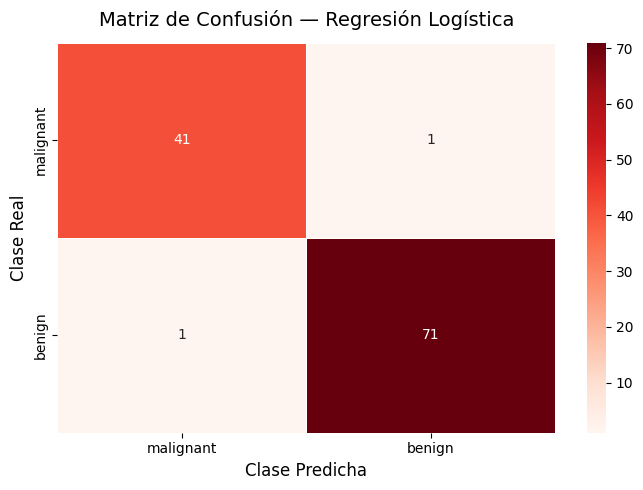

Verdaderos Negativos (TN) — malignos correctos: 41
Falsos Positivos  (FP)  — malignos detectados como benignos: 1
Falsos Negativos  (FN)  — benignos detectados como malignos: 1
Verdaderos Positivos (TP) — benignos correctos: 71

  En diagnóstico médico, los FN son los más peligrosos:
   Un tumor maligno clasificado como benigno puede costar una vida.


In [28]:
# La matriz de confusión nos dice cuántas predicciones acertamos y cuántas fallamos
# Filas = clase real, Columnas = clase predicha
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            linewidths=0.5, ax=ax)

ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=14, pad=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretamos los resultados
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN) — malignos correctos: {tn}')
print(f'Falsos Positivos  (FP)  — malignos detectados como benignos: {fp}')
print(f'Falsos Negativos  (FN)  — benignos detectados como malignos: {fn}')
print(f'Verdaderos Positivos (TP) — benignos correctos: {tp}')
print()
print('  En diagnóstico médico, los FN son los más peligrosos:')
print('   Un tumor maligno clasificado como benigno puede costar una vida.')

## 5. Métricas: Precisión, Recall, F1-Score y AUC-ROC

In [31]:
# Calculamos cada métrica por separado para entender qué mide cada una

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_prob)

print('=' * 70)
print('          MÉTRICAS DEL MODELO BASE')
print('=' * 70)
print(f'  Precisión  : {precision:.4f}  → De los que dije "benigno", ¿cuántos lo eran?')
print(f'  Recall     : {recall:.4f}  → De los benignos reales, ¿cuántos encontré?')
print(f'  F1-Score   : {f1:.4f}  → Balance entre precisión y recall')
print(f'  AUC-ROC    : {auc_roc:.4f}  → Qué tan bien separa el modelo las clases')
print('=' * 70)
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

          MÉTRICAS DEL MODELO BASE
  Precisión  : 0.9861  → De los que dije "benigno", ¿cuántos lo eran?
  Recall     : 0.9861  → De los benignos reales, ¿cuántos encontré?
  F1-Score   : 0.9861  → Balance entre precisión y recall
  AUC-ROC    : 0.9954  → Qué tan bien separa el modelo las clases

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6. Curva ROC

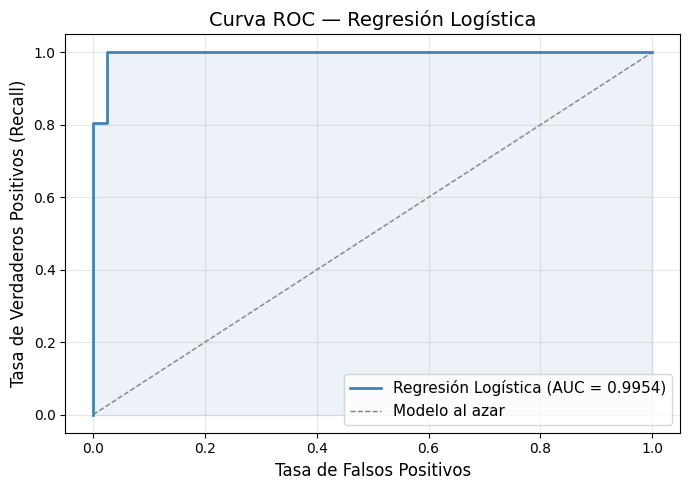

AUC-ROC = 0.9954 — el modelo es excelente para separar tumores malignos de benignos.


In [32]:
# La curva ROC muestra el balance entre sensibilidad (recall) y tasa de falsos positivos
# Un modelo perfecto tiene AUC = 1.0 y un modelo al azar tiene AUC = 0.5
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Regresión Logística (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Modelo al azar')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC — Regresión Logística', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC = {auc_roc:.4f} — el modelo es excelente para separar tumores malignos de benignos.')

## 7. K-Fold Cross-Validation con k=5 y k=10

In [33]:
# La validación cruzada nos da una idea más honesta del rendimiento del modelo
# porque lo prueba en varias particiones distintas del dataset

X_sc = scaler.fit_transform(X)  # escalamos todo el dataset para la validación cruzada

resultados = {}
for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X_sc, y, cv=kf, scoring='f1')
    resultados[k] = scores
    print(f'K-Fold k={k}:')
    print(f'  F1 por fold: {[f"{s:.4f}" for s in scores]}')
    print(f'  Media: {scores.mean():.4f} | Desviación estándar: {scores.std():.4f}')
    print()

K-Fold k=5:
  F1 por fold: ['0.9790', '0.9868', '0.9722', '0.9930', '0.9778']
  Media: 0.9818 | Desviación estándar: 0.0073

K-Fold k=10:
  F1 por fold: ['0.9877', '0.9836', '0.9863', '0.9873', '0.9873', '0.9394', '1.0000', '0.9841', '0.9524', '0.9863']
  Media: 0.9794 | Desviación estándar: 0.0176



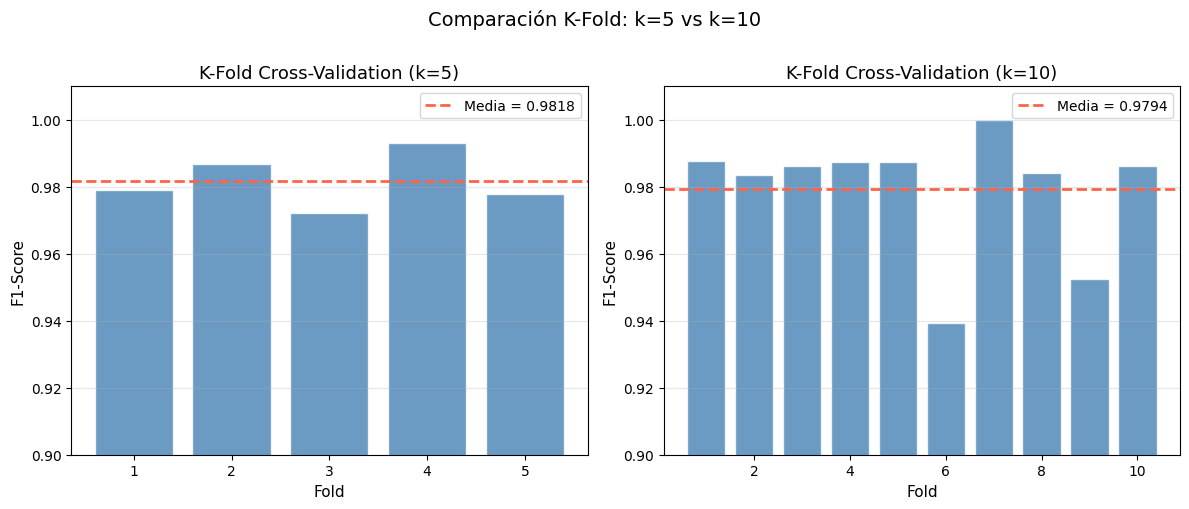

Conclusión:
  k=5  → media=0.9818, std=0.0073
  k=10 → media=0.9794, std=0.0176
  k=10 ofrece una estimación más estable pero tarda más en calcularse.


In [9]:
# Visualizamos la comparación entre k=5 y k=10
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, k in enumerate([5, 10]):
    scores = resultados[k]
    axes[i].bar(range(1, k+1), scores, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].axhline(scores.mean(), color='tomato', linestyle='--', lw=2, label=f'Media = {scores.mean():.4f}')
    axes[i].set_title(f'K-Fold Cross-Validation (k={k})', fontsize=13)
    axes[i].set_xlabel('Fold', fontsize=11)
    axes[i].set_ylabel('F1-Score', fontsize=11)
    axes[i].set_ylim(0.90, 1.01)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación K-Fold: k=5 vs k=10', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('kfold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conclusión:')
print(f'  k=5  → media={resultados[5].mean():.4f}, std={resultados[5].std():.4f}')
print(f'  k=10 → media={resultados[10].mean():.4f}, std={resultados[10].std():.4f}')
print('  k=10 ofrece una estimación más estable pero tarda más en calcularse.')

## 8. Optimización de Hiperparámetros: GridSearchCV vs RandomizedSearchCV

In [34]:
import time

# Definimos los hiperparámetros que queremos explorar
# C controla la regularización: valores pequeños = más regularización
# solver = algoritmo de optimización
# penalty = tipo de regularización

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'max_iter': [500, 1000]
}

# --- GridSearchCV: prueba TODAS las combinaciones posibles ---
t0 = time.time()
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)
t_grid = time.time() - t0

print(f'GridSearchCV')
print(f'  Mejores parámetros: {grid_search.best_params_}')
print(f'  Mejor F1 (CV):      {grid_search.best_score_:.4f}')
print(f'  Tiempo:             {t_grid:.2f} segundos')
print()

GridSearchCV
  Mejores parámetros: {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
  Mejor F1 (CV):      0.9845
  Tiempo:             0.47 segundos



In [35]:
from scipy.stats import loguniform

# --- RandomizedSearchCV: prueba solo un subconjunto aleatorio de combinaciones ---
# Es más rápido cuando el espacio de búsqueda es muy grande
param_dist = {
    'C': loguniform(0.001, 100),  # distribución logarítmica uniforme
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'max_iter': [500, 1000]
}

t0 = time.time()
random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_dist, n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
random_search.fit(X_train_sc, y_train)
t_random = time.time() - t0

print(f'RandomizedSearchCV')
print(f'  Mejores parámetros: {random_search.best_params_}')
print(f'  Mejor F1 (CV):      {random_search.best_score_:.4f}')
print(f'  Tiempo:             {t_random:.2f} segundos')
print()
print(f' GridSearch fue {t_grid/t_random:.1f}x más lento que RandomizedSearch')

RandomizedSearchCV
  Mejores parámetros: {'C': np.float64(0.14445251022763064), 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
  Mejor F1 (CV):      0.9845
  Tiempo:             0.35 segundos

 GridSearch fue 1.3x más lento que RandomizedSearch


In [36]:
# Comparamos el rendimiento de ambos métodos en el conjunto de prueba
mejor_modelo_grid   = grid_search.best_estimator_
mejor_modelo_random = random_search.best_estimator_

y_pred_grid   = mejor_modelo_grid.predict(X_test_sc)
y_pred_random = mejor_modelo_random.predict(X_test_sc)

print('Comparación en conjunto de prueba:')
print(f'  GridSearch    → F1: {f1_score(y_test, y_pred_grid):.4f}, AUC: {roc_auc_score(y_test, mejor_modelo_grid.predict_proba(X_test_sc)[:,1]):.4f}')
print(f'  RandomSearch  → F1: {f1_score(y_test, y_pred_random):.4f}, AUC: {roc_auc_score(y_test, mejor_modelo_random.predict_proba(X_test_sc)[:,1]):.4f}')

Comparación en conjunto de prueba:
  GridSearch    → F1: 0.9793, AUC: 0.9957
  RandomSearch  → F1: 0.9861, AUC: 0.9960


## 9. Ajuste del Umbral de Decisión

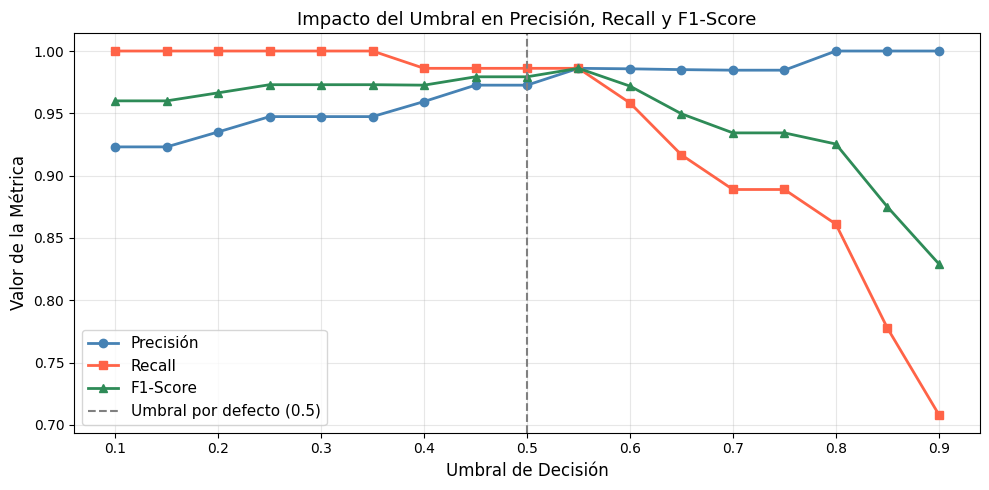

In [37]:
# Por defecto el umbral es 0.5 — si la probabilidad supera 0.5, predecimos clase 1 (benigno)
# Cambiar el umbral modifica el balance entre Precisión y Recall

# Usamos las probabilidades del mejor modelo de GridSearch
y_prob_opt = mejor_modelo_grid.predict_proba(X_test_sc)[:, 1]

umbrales = np.arange(0.1, 0.95, 0.05)
precisiones, recalls, f1_scores = [], [], []

for umbral in umbrales:
    y_pred_u = (y_prob_opt >= umbral).astype(int)
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_u, zero_division=0))

# Visualizamos cómo cambian las métricas al variar el umbral
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, precisiones, 'o-', color='steelblue', lw=2, label='Precisión')
ax.plot(umbrales, recalls,    's-', color='tomato',    lw=2, label='Recall')
ax.plot(umbrales, f1_scores,  '^-', color='seagreen',  lw=2, label='F1-Score')
ax.axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Umbral por defecto (0.5)')
ax.set_xlabel('Umbral de Decisión', fontsize=12)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title('Impacto del Umbral en Precisión, Recall y F1-Score', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Encontramos el umbral óptimo según el F1-Score
idx_mejor = np.argmax(f1_scores)
umbral_optimo = umbrales[idx_mejor]

print(f'Umbral óptimo (máximo F1): {umbral_optimo:.2f}')
print(f'  Precisión : {precisiones[idx_mejor]:.4f}')
print(f'  Recall    : {recalls[idx_mejor]:.4f}')
print(f'  F1-Score  : {f1_scores[idx_mejor]:.4f}')
print()
print('Comparación con umbral por defecto (0.5):')
idx_50 = np.argmin(np.abs(umbrales - 0.5))
print(f'  Precisión : {precisiones[idx_50]:.4f}')
print(f'  Recall    : {recalls[idx_50]:.4f}')
print(f'  F1-Score  : {f1_scores[idx_50]:.4f}')
print()
print('  En un contexto médico, bajar el umbral aumenta el Recall')
print('   (detectamos más tumores malignos) aunque baje un poco la Precisión.')

Umbral óptimo (máximo F1): 0.55
  Precisión : 0.9861
  Recall    : 0.9861
  F1-Score  : 0.9861

Comparación con umbral por defecto (0.5):
  Precisión : 0.9726
  Recall    : 0.9861
  F1-Score  : 0.9793

  En un contexto médico, bajar el umbral aumenta el Recall
   (detectamos más tumores malignos) aunque baje un poco la Precisión.


## 10. Resumen Visual Final

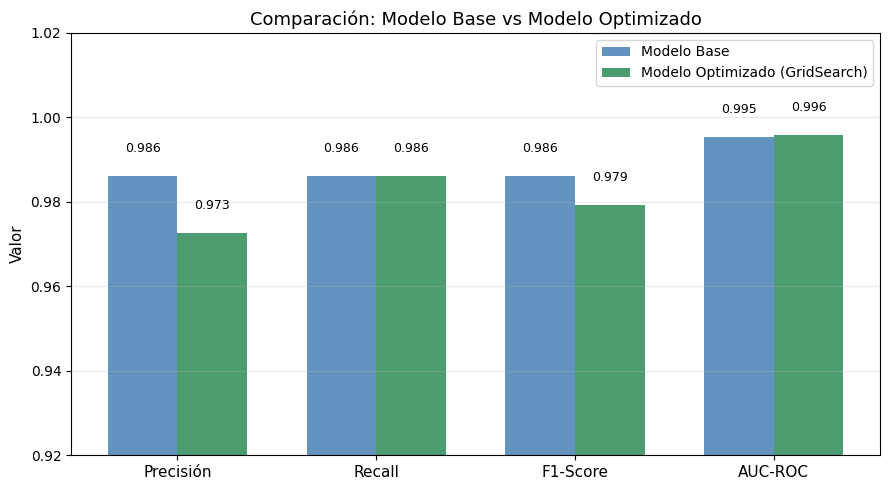

Análisis completo finalizado.


In [39]:
# Resumen de todas las métricas comparando modelo base vs modelo optimizado
metricas = ['Precisión', 'Recall', 'F1-Score', 'AUC-ROC']

vals_base = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
]
vals_opt = [
    precision_score(y_test, y_pred_grid),
    recall_score(y_test, y_pred_grid),
    f1_score(y_test, y_pred_grid),
    roc_auc_score(y_test, mejor_modelo_grid.predict_proba(X_test_sc)[:,1])
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, vals_base, width, label='Modelo Base', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, vals_opt,  width, label='Modelo Optimizado (GridSearch)', color='seagreen', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.92, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Comparación: Modelo Base vs Modelo Optimizado', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Análisis completo finalizado.')